# LAB 05: HOG-Based Industrial Defect Detection and Classification

## 1. Setup

In [18]:
!pip -q install kagglehub scikit-image opencv-python-headless seaborn

In [19]:
import os, glob, re, time, warnings
import xml.etree.ElementTree as ET
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from joblib import Parallel, delayed
from skimage.feature import hog
from skimage import exposure
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
sns.set_style('whitegrid')

In [20]:
OUT = 'figures'
os.makedirs(OUT, exist_ok=True)

def save(name):
    plt.savefig(f'{OUT}/{name}.png', dpi=150, bbox_inches='tight')

print(os.path.abspath(OUT))

/content/figures


## 2. Load Dataset

In [21]:
import kagglehub

candidates = [
    'sovitrath/neu-steel-surface-defect-detecttrainvalid-split',
    'sovitrath/neu-steel-surface-defect-detect-trainvalid-split',
    'sovitrath/neu-steel-surface-defect-detect-train-valid-split',
]

path = None
for attempt in range(2):
    for slug in candidates:
        try:
            path = kagglehub.dataset_download(slug)
            print('Downloaded:', slug)
            break
        except Exception as e:
            print('Failed:', slug, '->', type(e).__name__)
    if path or attempt == 1:
        break
    kagglehub.login()

if path is None:
    import zipfile
    from google.colab import files
    uploaded = files.upload()
    path = 'neu_data'
    for name in uploaded:
        with zipfile.ZipFile(name) as z:
            z.extractall(path)

print(path)

Failed: sovitrath/neu-steel-surface-defect-detecttrainvalid-split -> KaggleApiHTTPError
Using Colab cache for faster access to the 'neu-steel-surface-defect-detect-trainvalid-split' dataset.
Downloaded: sovitrath/neu-steel-surface-defect-detect-trainvalid-split
/kaggle/input/neu-steel-surface-defect-detect-trainvalid-split


In [22]:
exts = ('.jpg', '.jpeg', '.png', '.bmp')
all_files = glob.glob(path + '/**/*', recursive=True)
img_files = [p for p in all_files if p.lower().endswith(exts)]
xml_files = {os.path.splitext(os.path.basename(p))[0]: p for p in all_files if p.lower().endswith('.xml')}

def split_of(p):
    parts = os.path.relpath(p, path).lower().split(os.sep)
    return 'valid' if any(s.startswith('val') for s in parts[:-1]) else 'train'

def class_of(p):
    stem = os.path.splitext(os.path.basename(p))[0]
    return re.sub(r'_\d+.*$', '', stem)

def parse_boxes(xp):
    if xp is None:
        return []
    root = ET.parse(xp).getroot()
    out = []
    for o in root.findall('object'):
        b = o.find('bndbox')
        out.append(tuple(int(float(b.find(k).text)) for k in ('xmin', 'ymin', 'xmax', 'ymax')))
    return out

df = pd.DataFrame({
    'path': img_files,
    'split': [split_of(p) for p in img_files],
    'cls': [class_of(p) for p in img_files],
})
df['boxes'] = [parse_boxes(xml_files.get(os.path.splitext(os.path.basename(p))[0])) for p in df.path]

if 'valid' not in set(df.split):
    _, te_idx = train_test_split(df.index, test_size=0.2, stratify=df.cls, random_state=SEED)
    df.loc[te_idx, 'split'] = 'valid'

print(len(df), 'images,', len(xml_files), 'annotation files')

1800 images, 1800 annotation files


## 3. Dataset Inspection

In [23]:
display(pd.crosstab(df.cls, df.split, margins=True))
sizes = {cv2.imread(p).shape for p in df.path.sample(100, random_state=SEED)}
print('Image shapes:', sizes)
print('Images with boxes:', int((df.boxes.str.len() > 0).sum()))

split,train,valid,All
cls,,,
crazing,283,17,300
inclusion,283,17,300
patches,284,16,300
pitted_surface,283,17,300
rolled-in_scale,283,17,300
scratches,284,16,300
All,1700,100,1800


Image shapes: {(200, 200, 3)}
Images with boxes: 1800


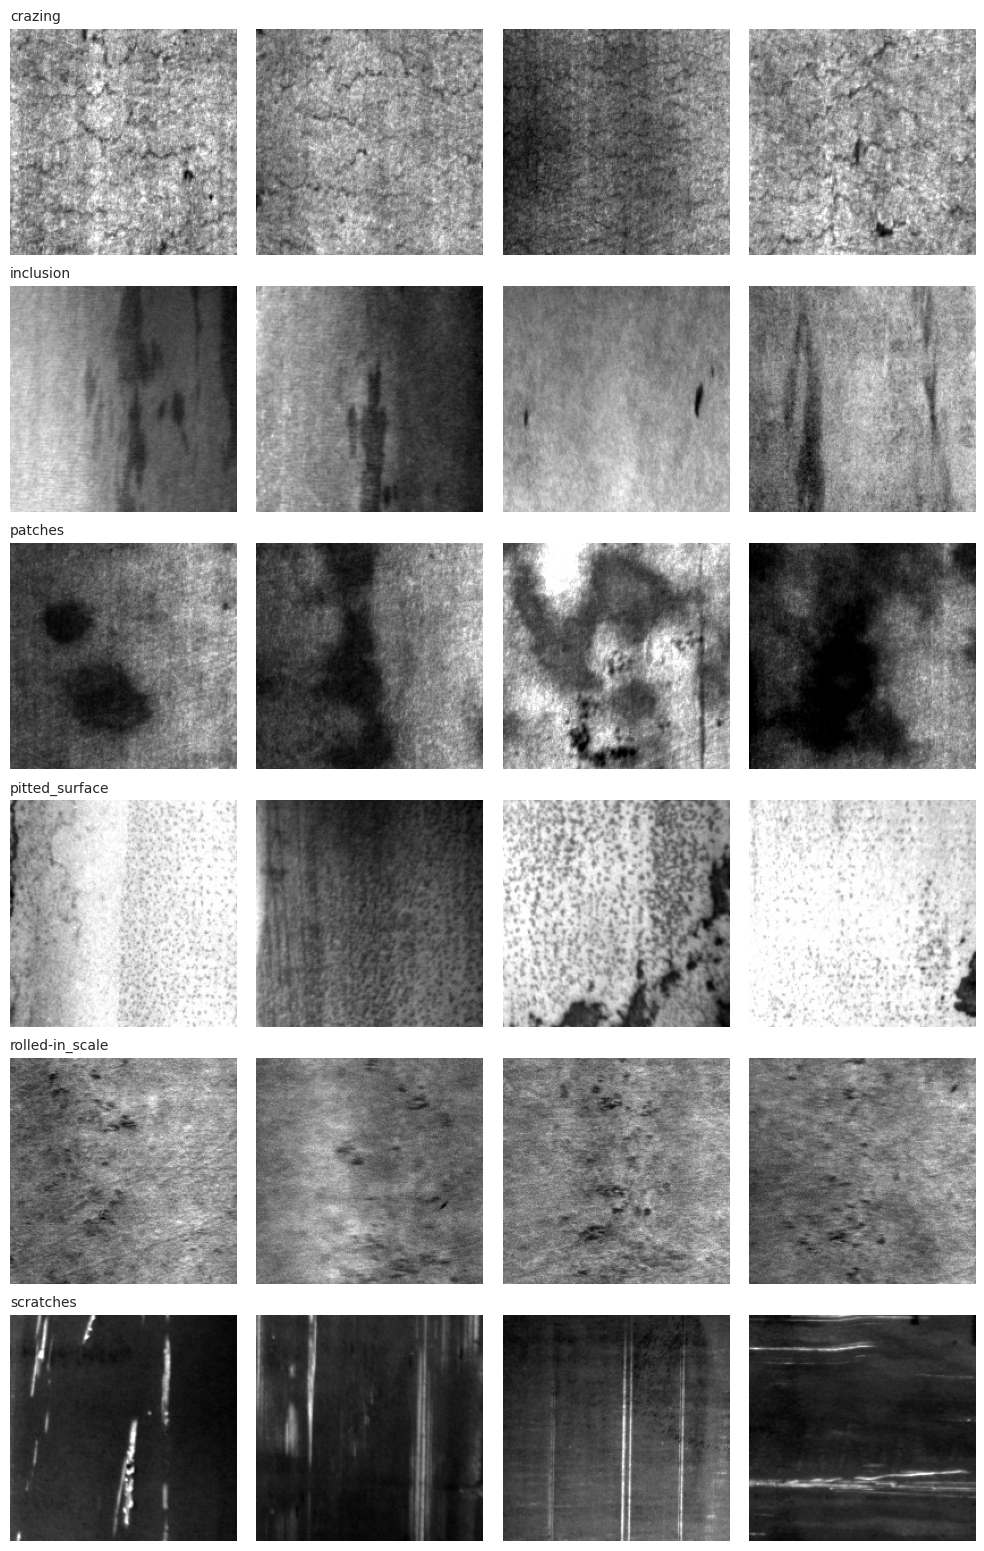

In [24]:
classes = sorted(df.cls.unique())
fig, axes = plt.subplots(len(classes), 4, figsize=(10, 2.6 * len(classes)))
for i, c in enumerate(classes):
    sub = df[(df.cls == c) & (df.split == 'train')].sample(4, random_state=SEED)
    for j, p in enumerate(sub.path):
        axes[i, j].imshow(cv2.imread(p, 0), cmap='gray')
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(c, loc='left', fontsize=10)
plt.tight_layout()
save('01_dataset_samples')
plt.show()

## 4. Preprocessing and Binary Dataset Construction

In [25]:
WIN = 100
IMG = 128

def preprocess(img):
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.resize(img, (IMG, IMG), interpolation=cv2.INTER_LINEAR)

def crop_defect(g, boxes):
    h, w = g.shape
    if boxes:
        x1, y1, x2, y2 = boxes[0]
        cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
    else:
        cx, cy = w // 2, h // 2
    x = int(np.clip(cx - WIN // 2, 0, w - WIN))
    y = int(np.clip(cy - WIN // 2, 0, h - WIN))
    return g[y:y + WIN, x:x + WIN]

def overlaps(x, y, b):
    return not (x + WIN <= b[0] or b[2] <= x or y + WIN <= b[1] or b[3] <= y)

def crop_normal(g, boxes, rng):
    h, w = g.shape
    cands = [(x, y) for y in range(0, h - WIN + 1, 20) for x in range(0, w - WIN + 1, 20)
             if not any(overlaps(x, y, b) for b in boxes)]
    if not cands:
        return None
    x, y = cands[rng.integers(len(cands))]
    return g[y:y + WIN, x:x + WIN]

def build_binary(split):
    rng = np.random.default_rng(SEED if split == 'train' else SEED + 1)
    X, y = [], []
    for r in df[df.split == split].itertuples():
        g = cv2.cvtColor(cv2.imread(r.path), cv2.COLOR_BGR2GRAY)
        X.append(preprocess(crop_defect(g, r.boxes)))
        y.append(1)
        if r.boxes:
            n = crop_normal(g, r.boxes, rng)
            if n is not None:
                X.append(preprocess(n))
                y.append(0)
    return np.array(X), np.array(y)

Xtrain_all, ytrain_all = build_binary('train')
Xte, yte = build_binary('valid')
Xtr, Xval, ytr, yval = train_test_split(Xtrain_all, ytrain_all, test_size=0.2,
                                        stratify=ytrain_all, random_state=SEED)

LABELS = ['Non-Defective', 'Defective']
pd.DataFrame({'Train': np.bincount(ytr), 'Validation': np.bincount(yval), 'Test': np.bincount(yte)},
             index=LABELS)

,Train,Validation,Test
Non-Defective,384,96,27
Defective,1360,340,100


## 5. HOG Feature Extraction

In [26]:
def hog_one(im, cell=8, ori=9):
    return hog(im, orientations=ori, pixels_per_cell=(cell, cell),
               cells_per_block=(2, 2), block_norm='L2-Hys')

def extract(imgs, cell=8, ori=9):
    feats = Parallel(n_jobs=-1)(delayed(hog_one)(im, cell, ori) for im in imgs)
    return np.array(feats, dtype=np.float32)

DEF_CELL, DEF_ORI = 8, 9
Ftr, Fval, Fte = [extract(X, DEF_CELL, DEF_ORI) for X in (Xtr, Xval, Xte)]
print(Ftr.shape, Fval.shape, Fte.shape)

(1744, 8100) (436, 8100) (127, 8100)


## 6. HOG Visualization

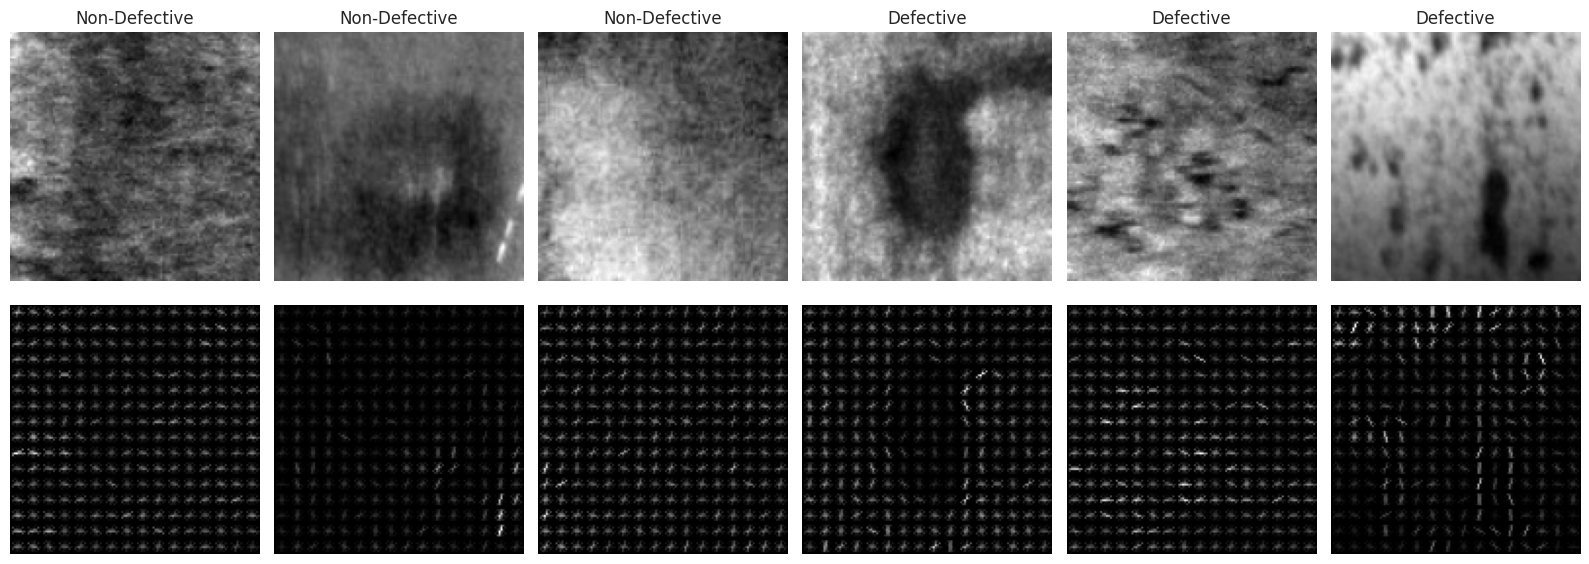

In [27]:
idx0 = np.where(ytr == 0)[0][:3]
idx1 = np.where(ytr == 1)[0][:3]
sel = list(idx0) + list(idx1)

fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for k, i in enumerate(sel):
    _, himg = hog(Xtr[i], orientations=DEF_ORI, pixels_per_cell=(DEF_CELL, DEF_CELL),
                  cells_per_block=(2, 2), block_norm='L2-Hys', visualize=True)
    himg = exposure.rescale_intensity(himg, in_range=(0, himg.max() + 1e-9))
    axes[0, k].imshow(Xtr[i], cmap='gray')
    axes[0, k].set_title(LABELS[ytr[i]])
    axes[1, k].imshow(himg, cmap='gray')
    axes[0, k].axis('off')
    axes[1, k].axis('off')
plt.tight_layout()
save('02_hog_representation')
plt.show()

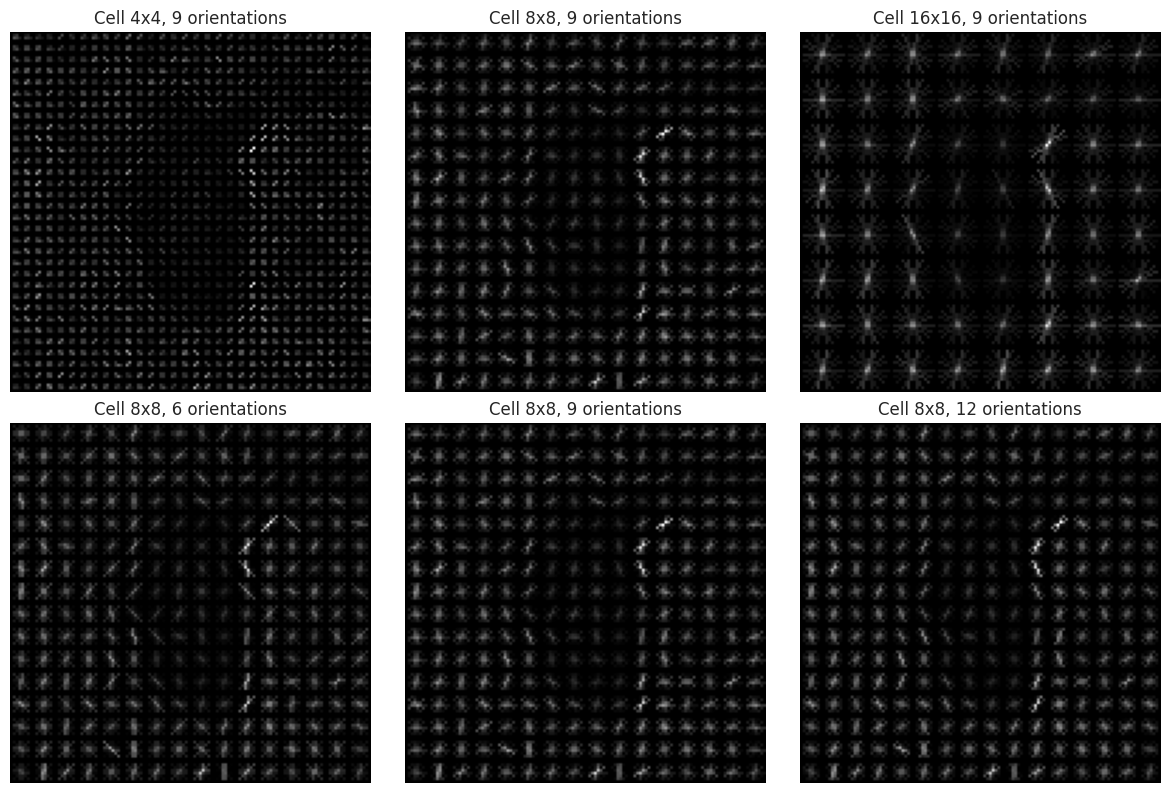

In [28]:
im = Xtr[idx1[0]]
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for j, cell in enumerate((4, 8, 16)):
    _, h1 = hog(im, orientations=9, pixels_per_cell=(cell, cell), cells_per_block=(2, 2), visualize=True)
    axes[0, j].imshow(exposure.rescale_intensity(h1, in_range=(0, h1.max() + 1e-9)), cmap='gray')
    axes[0, j].set_title(f'Cell {cell}x{cell}, 9 orientations')
for j, ori in enumerate((6, 9, 12)):
    _, h2 = hog(im, orientations=ori, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)
    axes[1, j].imshow(exposure.rescale_intensity(h2, in_range=(0, h2.max() + 1e-9)), cmap='gray')
    axes[1, j].set_title(f'Cell 8x8, {ori} orientations')
for a in axes.ravel():
    a.axis('off')
plt.tight_layout()
save('03_hog_parameters_visual')
plt.show()

## 7. SVM Classifier

In [29]:
def make_svm(prob=False):
    return SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
               probability=prob, random_state=SEED)

def make_rf():
    return RandomForestClassifier(n_estimators=200, class_weight='balanced', n_jobs=-1, random_state=SEED)

def make_knn():
    return KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)

def metric_row(y, p, avg='binary'):
    return {'Accuracy': accuracy_score(y, p),
            'Precision': precision_score(y, p, average=avg, zero_division=0),
            'Recall': recall_score(y, p, average=avg, zero_division=0),
            'F1-score': f1_score(y, p, average=avg, zero_division=0)}

results = {}
t = time.time()
svm = make_svm().fit(Ftr, ytr)
results['HOG + SVM'] = (svm, svm.predict(Fte), time.time() - t)
print(metric_row(yte, results['HOG + SVM'][1]))

{'Accuracy': 0.8661417322834646, 'Precision': 0.8807339449541285, 'Recall': 0.96, 'F1-score': 0.9186602870813397}


## 8. Additional Classifiers

In [30]:
t = time.time()
rf = make_rf().fit(Ftr, ytr)
results['HOG + Random Forest'] = (rf, rf.predict(Fte), time.time() - t)

t = time.time()
knn = make_knn().fit(Ftr, ytr)
results['HOG + KNN'] = (knn, knn.predict(Fte), time.time() - t)

for k, v in results.items():
    print(k, metric_row(yte, v[1]))

HOG + SVM {'Accuracy': 0.8661417322834646, 'Precision': 0.8807339449541285, 'Recall': 0.96, 'F1-score': 0.9186602870813397}
HOG + Random Forest {'Accuracy': 0.8503937007874016, 'Precision': 0.8403361344537815, 'Recall': 1.0, 'F1-score': 0.91324200913242}
HOG + KNN {'Accuracy': 0.5039370078740157, 'Precision': 0.9743589743589743, 'Recall': 0.38, 'F1-score': 0.5467625899280576}


## 9. Classifier Comparison

,Accuracy,Precision,Recall,F1-score,Train Time (s)
HOG + SVM,0.8661,0.8807,0.96,0.9187,13.3142
HOG + Random Forest,0.8504,0.8403,1.00,0.9132,18.2181
HOG + KNN,0.5039,0.9744,0.38,0.5468,0.2006


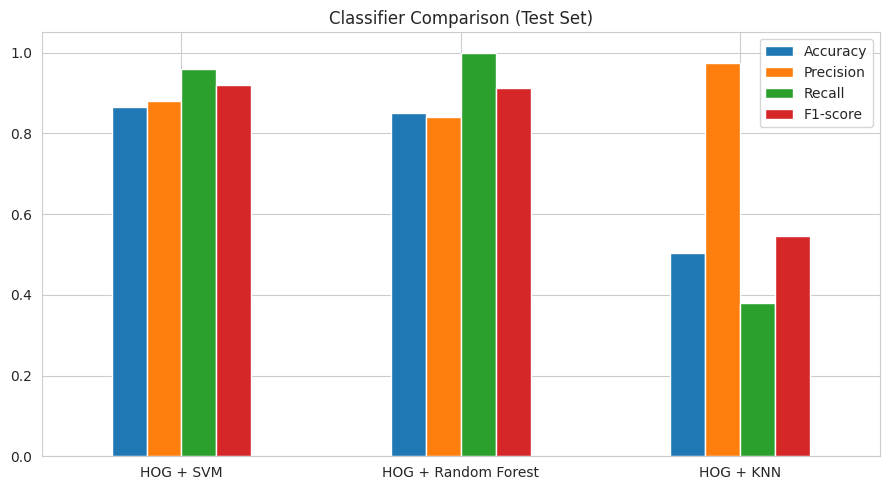

In [31]:
comp = pd.DataFrame({k: {**metric_row(yte, v[1]), 'Train Time (s)': v[2]} for k, v in results.items()}).T.round(4)
display(comp)
comp.to_csv(f'{OUT}/classifier_comparison.csv')

comp[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(kind='bar', figsize=(9, 5), rot=0)
plt.ylim(0, 1.05)
plt.title('Classifier Comparison (Test Set)')
plt.tight_layout()
save('04_classifier_comparison')
plt.show()

## 10. Confusion Matrix and Classification Report

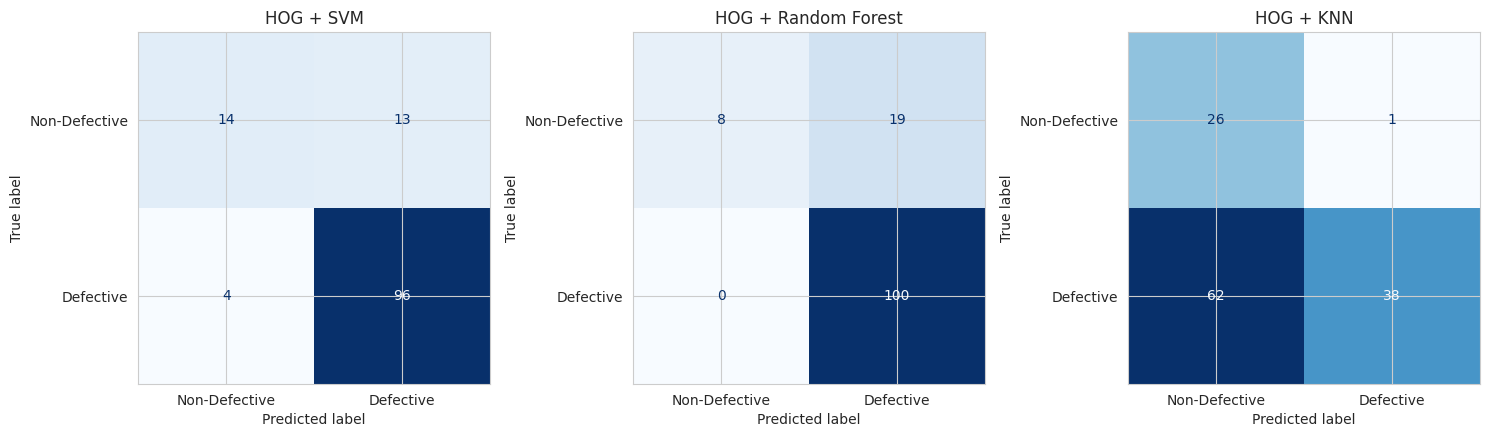

HOG + SVM
               precision    recall  f1-score   support

Non-Defective     0.7778    0.5185    0.6222        27
    Defective     0.8807    0.9600    0.9187       100

     accuracy                         0.8661       127
    macro avg     0.8293    0.7393    0.7704       127
 weighted avg     0.8588    0.8661    0.8556       127

HOG + Random Forest
               precision    recall  f1-score   support

Non-Defective     1.0000    0.2963    0.4571        27
    Defective     0.8403    1.0000    0.9132       100

     accuracy                         0.8504       127
    macro avg     0.9202    0.6481    0.6852       127
 weighted avg     0.8743    0.8504    0.8163       127

HOG + KNN
               precision    recall  f1-score   support

Non-Defective     0.2955    0.9630    0.4522        27
    Defective     0.9744    0.3800    0.5468       100

     accuracy                         0.5039       127
    macro avg     0.6349    0.6715    0.4995       127
 weighted avg    

In [32]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 4.5))
for ax, (k, v) in zip(axes, results.items()):
    ConfusionMatrixDisplay(confusion_matrix(yte, v[1]), display_labels=LABELS).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(k)
plt.tight_layout()
save('05_confusion_matrices')
plt.show()

for k, v in results.items():
    print(k)
    print(classification_report(yte, v[1], target_names=LABELS, digits=4))

## 11. HOG Parameter Study

In [33]:
rows = []
for cell in (4, 8, 16):
    for ori in (6, 9, 12):
        a = extract(Xtr, cell, ori)
        b = extract(Xval, cell, ori)
        for name, mk in (('SVM', make_svm), ('Random Forest', make_rf)):
            t = time.time()
            m = mk().fit(a, ytr)
            p = m.predict(b)
            rows.append({'Cell': f'{cell}x{cell}', 'Orientations': ori, 'Model': name,
                         'Features': a.shape[1],
                         'Accuracy': accuracy_score(yval, p), 'F1-score': f1_score(yval, p),
                         'Time (s)': time.time() - t})
        print('done', cell, ori)

grid = pd.DataFrame(rows).round(4)
grid.to_csv(f'{OUT}/hog_parameter_study.csv', index=False)
display(grid)

done 4 6
done 4 9
done 4 12
done 8 6
done 8 9
done 8 12
done 16 6
done 16 9
done 16 12


,Cell,Orientations,Model,Features,Accuracy,F1-score,Time (s)
0,4x4,6,SVM,23064,0.8372,0.9044,47.4755
1,4x4,6,Random Forest,23064,0.7913,0.8820,29.0243
2,4x4,9,SVM,34596,0.8211,0.8960,66.9584
3,4x4,9,Random Forest,34596,0.7844,0.8786,29.0006
4,4x4,12,SVM,46128,0.8257,0.8978,92.8815
5,4x4,12,Random Forest,46128,0.7982,0.8854,26.6685
6,8x8,6,SVM,5400,0.8647,0.9182,18.0101
7,8x8,6,Random Forest,5400,0.8142,0.8936,16.1982
8,8x8,9,SVM,8100,0.8486,0.9106,15.3420
9,8x8,9,Random Forest,8100,0.8119,0.8924,18.8589


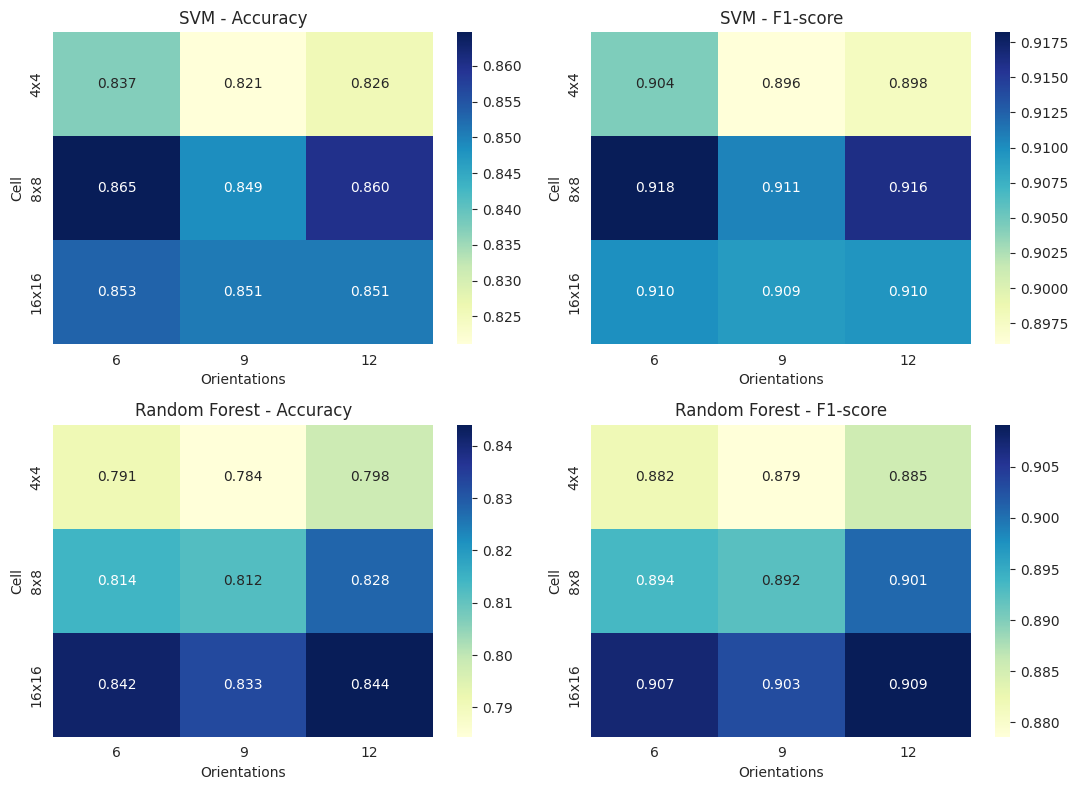

Best SVM config: 8 x 8 , 6 orientations


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for i, name in enumerate(('SVM', 'Random Forest')):
    for j, metric in enumerate(('Accuracy', 'F1-score')):
        pv = grid[grid.Model == name].pivot(index='Cell', columns='Orientations', values=metric)
        pv = pv.loc[['4x4', '8x8', '16x16']]
        sns.heatmap(pv, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[i, j])
        axes[i, j].set_title(f'{name} - {metric}')
plt.tight_layout()
save('06_hog_parameter_heatmaps')
plt.show()

best = grid[grid.Model == 'SVM'].sort_values('F1-score', ascending=False).iloc[0]
BEST_CELL = int(best.Cell.split('x')[0])
BEST_ORI = int(best.Orientations)
print('Best SVM config:', BEST_CELL, 'x', BEST_CELL, ',', BEST_ORI, 'orientations')

## 12. Final Model

,Accuracy,Precision,Recall,F1-score
SVM,0.8583,0.8796,0.95,0.9135
Random Forest,0.8425,0.8333,1.00,0.9091


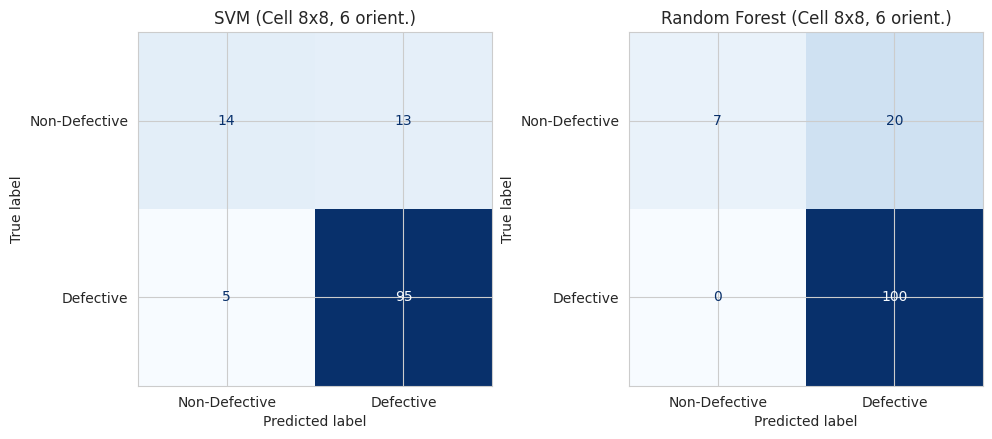

In [35]:
Ftr_b = extract(Xtr, BEST_CELL, BEST_ORI)
Fte_b = extract(Xte, BEST_CELL, BEST_ORI)

svm_final = make_svm(prob=True).fit(Ftr_b, ytr)
rf_final = make_rf().fit(Ftr_b, ytr)

final = pd.DataFrame({
    'SVM': metric_row(yte, svm_final.predict(Fte_b)),
    'Random Forest': metric_row(yte, rf_final.predict(Fte_b)),
}).T.round(4)
display(final)
final.to_csv(f'{OUT}/final_model_metrics.csv')

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, (n, m) in zip(axes, (('SVM', svm_final), ('Random Forest', rf_final))):
    ConfusionMatrixDisplay(confusion_matrix(yte, m.predict(Fte_b)), display_labels=LABELS).plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{n} (Cell {BEST_CELL}x{BEST_CELL}, {BEST_ORI} orient.)')
plt.tight_layout()
save('07_final_confusion_matrices')
plt.show()

## 13. Robustness Analysis

In [36]:
def brightness(im, f):
    return np.clip(im.astype(np.float32) * f, 0, 255).astype(np.uint8)

def gnoise(im, s):
    n = np.random.default_rng(SEED).normal(0, s, im.shape)
    return np.clip(im.astype(np.float32) + n, 0, 255).astype(np.uint8)

def blur(im, k):
    return cv2.GaussianBlur(im, (k, k), 0)

def rotate(im, a):
    M = cv2.getRotationMatrix2D((IMG / 2, IMG / 2), a, 1.0)
    return cv2.warpAffine(im, M, (IMG, IMG), borderMode=cv2.BORDER_REFLECT)

conds = [('Original', None, None),
         ('Brightness', brightness, 0.6), ('Brightness', brightness, 1.5),
         ('Gaussian Noise', gnoise, 10), ('Gaussian Noise', gnoise, 25),
         ('Blur', blur, 5), ('Blur', blur, 9),
         ('Rotation', rotate, 10), ('Rotation', rotate, 30)]

rob_rows = []
for name, fn, par in conds:
    Xp = Xte if fn is None else np.array([fn(im, par) for im in Xte])
    F = extract(Xp, BEST_CELL, BEST_ORI)
    for mn, m in (('SVM', svm_final), ('Random Forest', rf_final)):
        p = m.predict(F)
        rob_rows.append({'Condition': name if par is None else f'{name} ({par})', 'Model': mn,
                         'Accuracy': accuracy_score(yte, p), 'F1-score': f1_score(yte, p)})

rob = pd.DataFrame(rob_rows)
base = rob[rob.Condition == 'Original'].set_index('Model')
rob['Acc Change'] = rob.apply(lambda r: r['Accuracy'] - base.loc[r.Model, 'Accuracy'], axis=1)
rob['F1 Change'] = rob.apply(lambda r: r['F1-score'] - base.loc[r.Model, 'F1-score'], axis=1)
rob = rob.round(4)
rob.to_csv(f'{OUT}/robustness_results.csv', index=False)
display(rob)

,Condition,Model,Accuracy,F1-score,Acc Change,F1 Change
0,Original,SVM,0.8583,0.9135,0.0000,0.0000
1,Original,Random Forest,0.8425,0.9091,0.0000,0.0000
2,Brightness (0.6),SVM,0.8346,0.8912,-0.0236,-0.0223
3,Brightness (0.6),Random Forest,0.8898,0.9346,0.0472,0.0255
4,Brightness (1.5),SVM,0.8583,0.9135,0.0000,0.0000
5,Brightness (1.5),Random Forest,0.8583,0.9174,0.0157,0.0083
6,Gaussian Noise (10),SVM,0.7008,0.8224,-0.1575,-0.0910
7,Gaussian Noise (10),Random Forest,0.7874,0.8811,-0.0551,-0.0280
8,Gaussian Noise (25),SVM,0.7717,0.8700,-0.0866,-0.0435
9,Gaussian Noise (25),Random Forest,0.7795,0.8761,-0.0630,-0.0330


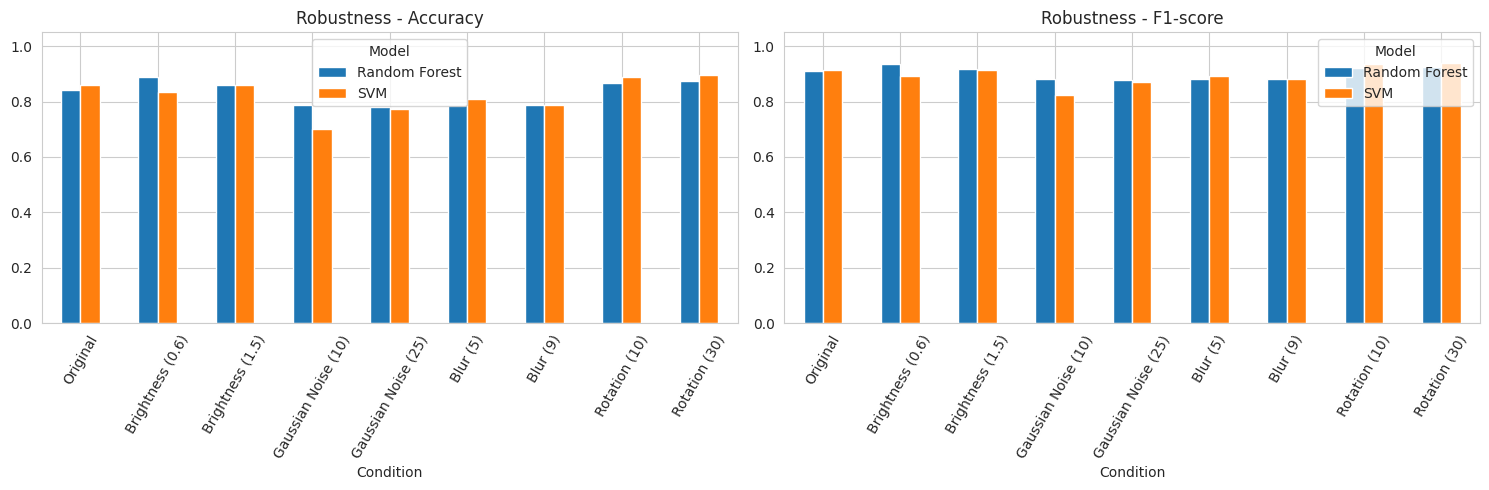

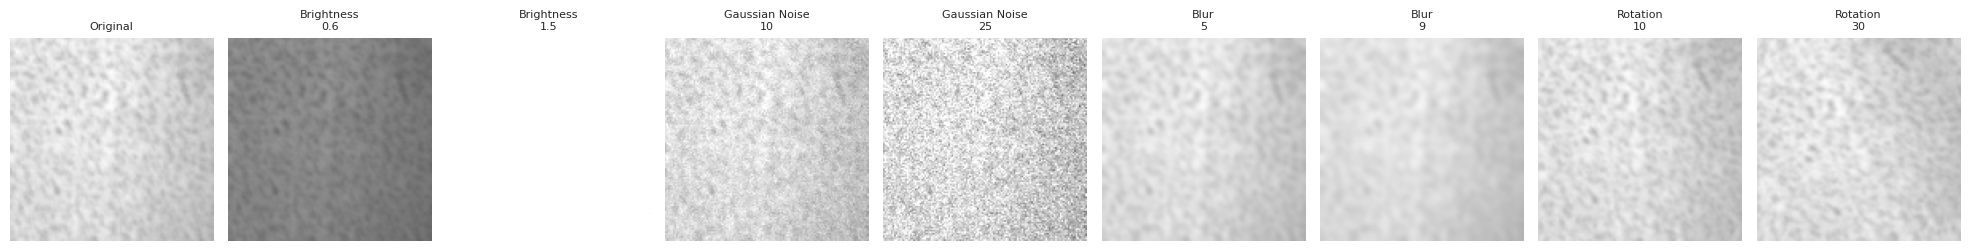

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, metric in zip(axes, ('Accuracy', 'F1-score')):
    pv = rob.pivot(index='Condition', columns='Model', values=metric).loc[rob.Condition.unique()]
    pv.plot(kind='bar', ax=ax, rot=60)
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Robustness - {metric}')
plt.tight_layout()
save('08_robustness')
plt.show()

samp = Xte[np.where(yte == 1)[0][0]]
fig, axes = plt.subplots(1, len(conds), figsize=(2.2 * len(conds), 2.8))
for ax, (name, fn, par) in zip(axes, conds):
    ax.imshow(samp if fn is None else fn(samp, par), cmap='gray', vmin=0, vmax=255)
    ax.set_title(name if par is None else f'{name}\n{par}', fontsize=8)
    ax.axis('off')
plt.tight_layout()
save('09_robustness_examples')
plt.show()

## 14. Multi-Class Defect Classification

,Accuracy,Precision,Recall,F1-score
SVM,0.89,0.8913,0.8909,0.8864
Random Forest,0.79,0.8098,0.7886,0.7887


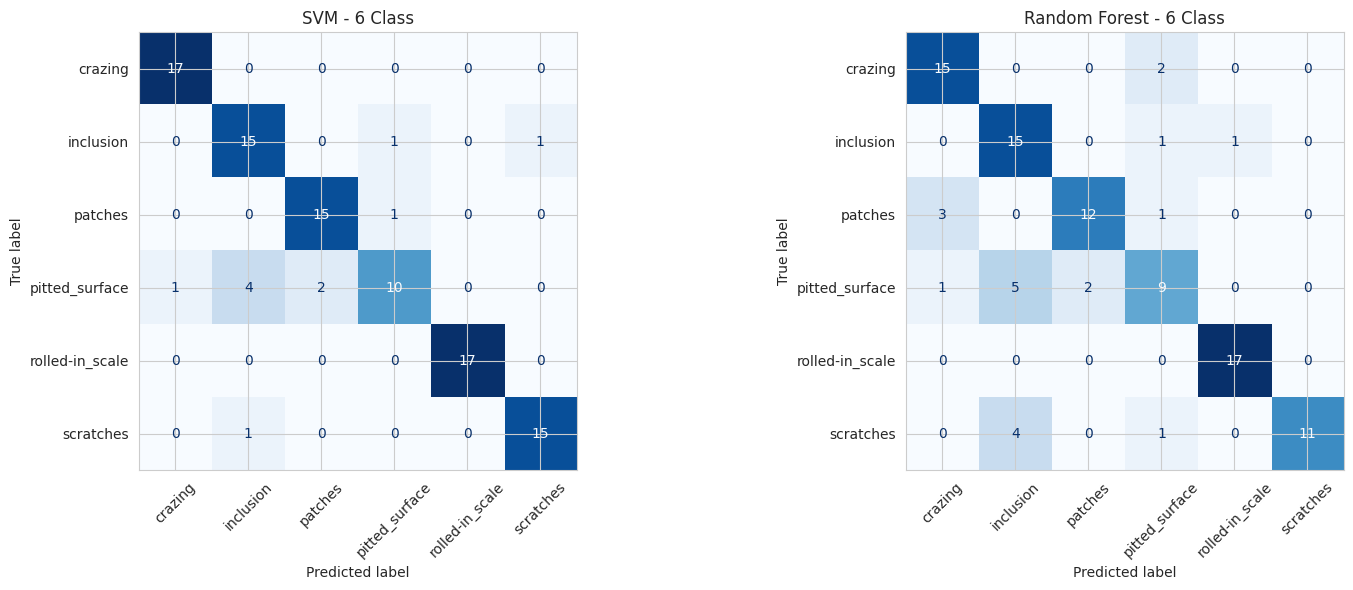

SVM
                 precision    recall  f1-score   support

        crazing     0.9444    1.0000    0.9714        17
      inclusion     0.7500    0.8824    0.8108        17
        patches     0.8824    0.9375    0.9091        16
 pitted_surface     0.8333    0.5882    0.6897        17
rolled-in_scale     1.0000    1.0000    1.0000        17
      scratches     0.9375    0.9375    0.9375        16

       accuracy                         0.8900       100
      macro avg     0.8913    0.8909    0.8864       100
   weighted avg     0.8909    0.8900    0.8857       100

Random Forest
                 precision    recall  f1-score   support

        crazing     0.7895    0.8824    0.8333        17
      inclusion     0.6250    0.8824    0.7317        17
        patches     0.8571    0.7500    0.8000        16
 pitted_surface     0.6429    0.5294    0.5806        17
rolled-in_scale     0.9444    1.0000    0.9714        17
      scratches     1.0000    0.6875    0.8148        16

       a

In [38]:
cid = {c: i for i, c in enumerate(classes)}

def load_multi(split):
    sub = df[df.split == split]
    X = np.array([preprocess(cv2.imread(p)) for p in sub.path])
    return X, sub.cls.map(cid).values

Xm_tr, ym_tr = load_multi('train')
Xm_te, ym_te = load_multi('valid')
Fm_tr = extract(Xm_tr, BEST_CELL, BEST_ORI)
Fm_te = extract(Xm_te, BEST_CELL, BEST_ORI)

multi = {}
for name, mk in (('SVM', make_svm), ('Random Forest', make_rf)):
    m = mk().fit(Fm_tr, ym_tr)
    multi[name] = m.predict(Fm_te)

mc = pd.DataFrame({k: metric_row(ym_te, p, 'macro') for k, p in multi.items()}).T.round(4)
display(mc)
mc.to_csv(f'{OUT}/multiclass_metrics.csv')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (k, p) in zip(axes, multi.items()):
    ConfusionMatrixDisplay(confusion_matrix(ym_te, p), display_labels=classes).plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(f'{k} - 6 Class')
plt.tight_layout()
save('10_multiclass_confusion')
plt.show()

for k, p in multi.items():
    print(k)
    print(classification_report(ym_te, p, target_names=classes, digits=4))

## 15. Quality-Control Decision Module

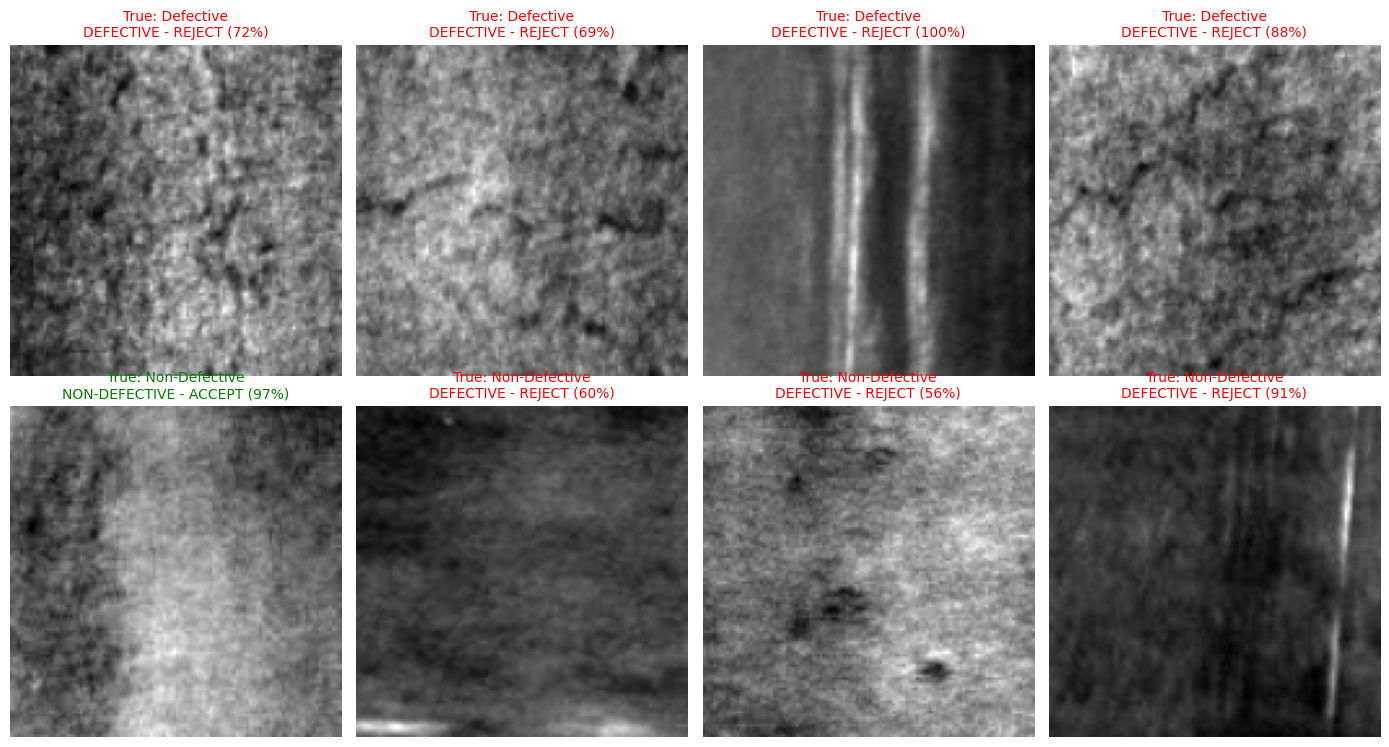

PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 72.0%
Action: REJECT PRODUCT

PRODUCT INSPECTION RESULT
Prediction: DEFECTIVE
Confidence: 91.0%
Action: REJECT PRODUCT



(1, np.float64(91.00318944768017))

In [39]:
def inspect_product(img, model=None, threshold=0.5, verbose=True):
    model = model or svm_final
    f = np.array([hog_one(preprocess(img), BEST_CELL, BEST_ORI)], dtype=np.float32)
    prob = model.predict_proba(f)[0]
    pred = int(prob[1] >= threshold)
    conf = prob[pred] * 100
    if verbose:
        print('PRODUCT INSPECTION RESULT')
        print('Prediction:', 'DEFECTIVE' if pred else 'NON-DEFECTIVE')
        print(f'Confidence: {conf:.1f}%')
        print('Action:', 'REJECT PRODUCT' if pred else 'ACCEPT PRODUCT')
        print()
    return pred, conf

rng = np.random.default_rng(SEED)
demo = list(rng.choice(np.where(yte == 1)[0], 4, replace=False)) + list(rng.choice(np.where(yte == 0)[0], 4, replace=False))

fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
for ax, i in zip(axes.ravel(), demo):
    pred, conf = inspect_product(Xte[i], verbose=False)
    ax.imshow(Xte[i], cmap='gray')
    ax.set_title(f"True: {LABELS[yte[i]]}\n{'DEFECTIVE - REJECT' if pred else 'NON-DEFECTIVE - ACCEPT'} ({conf:.0f}%)",
                 color='red' if pred else 'green', fontsize=10)
    ax.axis('off')
plt.tight_layout()
save('11_qc_decisions')
plt.show()

inspect_product(Xte[demo[0]])
inspect_product(Xte[demo[-1]])

## 16. Bonus: Real-Time Prototype

Average latency: 18.2 ms/frame, 55.0 FPS
Saved: figures/bonus_stream.mp4


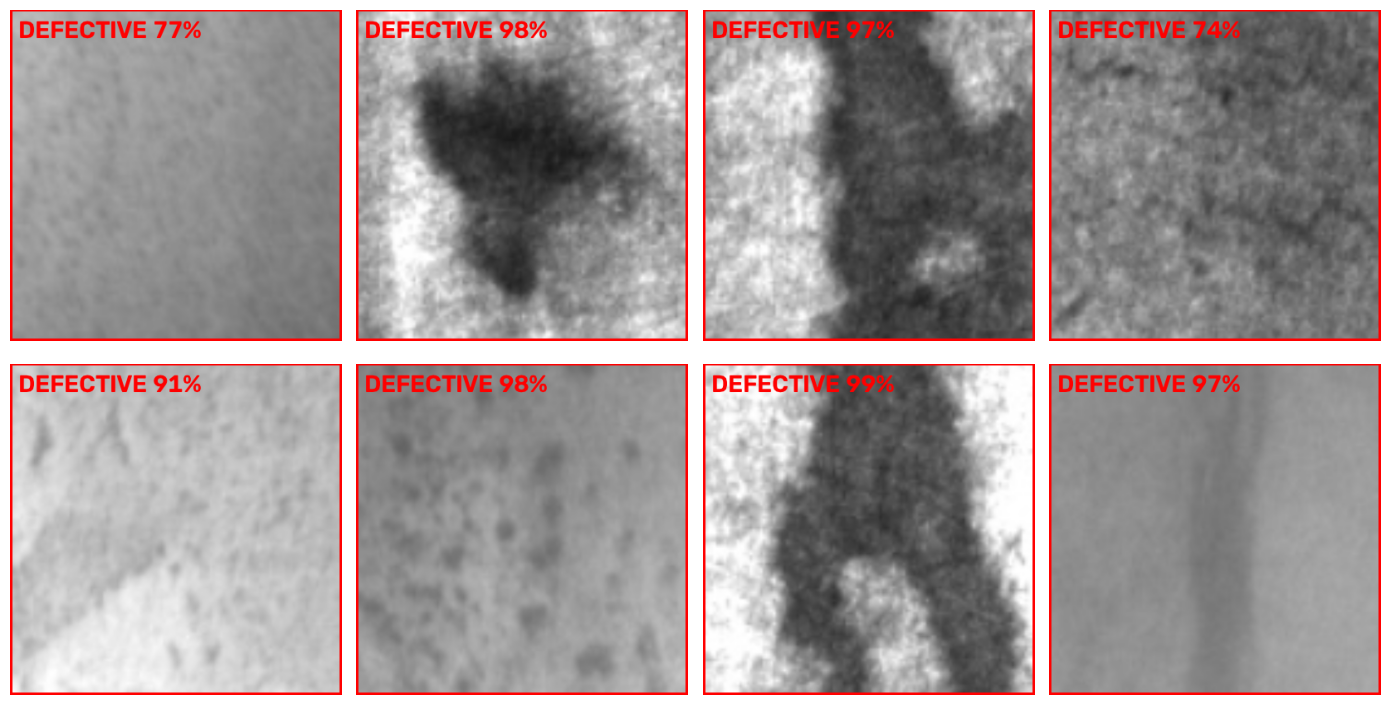

In [40]:
def annotate(frame, model=None):
    model = model or svm_final
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    s = min(h, w)
    y, x = (h - s) // 2, (w - s) // 2
    f = np.array([hog_one(preprocess(gray[y:y + s, x:x + s]), BEST_CELL, BEST_ORI)], dtype=np.float32)
    prob = model.predict_proba(f)[0]
    pred = int(prob[1] >= 0.5)
    conf = prob[pred] * 100
    label = 'DEFECTIVE' if pred else 'PASS'
    color = (0, 0, 255) if pred else (0, 200, 0)
    out = frame.copy()
    cv2.rectangle(out, (x, y), (x + s - 1, y + s - 1), color, 4)
    cv2.putText(out, f'{label} {conf:.0f}%', (x + 10, y + 35), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)
    return out, pred, conf

idx = np.random.default_rng(SEED).choice(len(Xte), 24, replace=False)
video_path = f'{OUT}/bonus_stream.mp4'
vw = cv2.VideoWriter(video_path, cv2.VideoWriter_fourcc(*'mp4v'), 10, (400, 400))
lat, frames = [], []
for i in idx:
    fr = cv2.cvtColor(cv2.resize(Xte[i], (400, 400)), cv2.COLOR_GRAY2BGR)
    t = time.time()
    out, pred, conf = annotate(fr)
    lat.append(time.time() - t)
    frames.append(out)
    for _ in range(5):
        vw.write(out)
vw.release()

print(f'Average latency: {np.mean(lat) * 1000:.1f} ms/frame, {1 / np.mean(lat):.1f} FPS')
print('Saved:', video_path)

fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
for ax, fr in zip(axes.ravel(), frames[:8]):
    ax.imshow(cv2.cvtColor(fr, cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.tight_layout()
save('12_bonus_stream_frames')
plt.show()

In [41]:
def run_webcam(cam=0):
    cap = cv2.VideoCapture(cam)
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        out, pred, conf = annotate(frame)
        cv2.imshow('Lab05 Inspection (press q to quit)', out)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    cap.release()
    cv2.destroyAllWindows()